# Spacecraft Geometry and Self-Occlusion Demo

This notebook is the working demo for the body-fixed spacecraft geometry layer and the realized-geometry JSON handoff into the view-factor workflow.

What it does:
- builds the default 6U double-deployable CubeSat example
- chooses one explicit mechanism state and one geometry-frame -> body-frame mount
- realizes the body-frame geometry once, plots it with explicit body axes, and saves it to `outputs/spacecraft.json`
- prints a compact surface summary
- verifies the mounted body-normal mapping used by the attitude laws
- confirms nearest-hit ray queries on the mounted geometry
- computes a patch-by-ray spacecraft self-occlusion mask
- visualizes blocked directions from one mounted bus face
- maps the average blockage back onto that face patch grid

Run the cells from top to bottom.


In [1]:
import math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from geometry import build_6u_double_deployable, mount
from viewfactor import spacecraft_occlusion_mask


## Frame Convention

Keep the builder geometry in its own geometry frame, then realize once into the downstream body frame. Hinge angles resolve the internal mechanism state, and `mount(...)` makes the geometry-frame -> body-frame attachment explicit at the call site.

Use the three layers like this:
- geometry change: edit bus dimensions, hinge locations, or the deployment `mechanism_state`
- mount change: edit `mount_rotation = mount(...)` or `mount_offset`
- attitude change: edit the `SO3` law that maps body vectors into LVLH or ECI in downstream propagation

After mounting, downstream body-axis roles are defined by each surface normal, not by the original stable builder name. The JSON keeps those stable names, but analysis should interpret body-facing roles from the realized normals.


In [2]:
from geometry.CubeSat.inspect import (
    surface_by_normal, face_frame_labels,
    signed_axis_label, opposite_axis_label,
    print_surface_summary, print_mounted_role_table,
)
from geometry.CubeSat.plots import plot_realized_geometry
from viewfactor.sampling import hemisphere_directions
from viewfactor.plots import plot_occlusion_heatmap, plot_patch_occlusion_map


## Step 1: Build the default 6U example

Here we attach patch grids to the bus and wing surfaces. Those patch grids are not adding thickness; they just give the later occlusion and view-factor steps a patch-by-patch source mesh to work with.

In [3]:
leaf_y = 0.2263  # panel-leaf dimension along body y [m]
leaf_z = 0.3405  # panel-leaf dimension along body z [m]
# Patch resolution only changes the sampling mesh on each surface, not the geometry itself.
bus_patch_shape = (12, 8)
wing_patch_shape = (12, 8)

mechanism_state = {
    'wing_port_inner_angle': math.pi / 2.0,
    'wing_port_outer_angle': math.pi,
    'wing_starboard_inner_angle': -math.pi / 2.0,
    'wing_starboard_outer_angle': -math.pi,
}
mount_rotation = mount('+Y', '+Z', '+Z', '+X')
mount_offset = np.array([0.0, 0.0, 0.0])
outputs_dir = Path('outputs')
geometry_json_path = outputs_dir / 'spacecraft.json'

cubesat = build_6u_double_deployable(
    leaf_y=leaf_y,
    leaf_z=leaf_z,
    bus_patch_shape=bus_patch_shape,
    wing_patch_shape=wing_patch_shape,
)

print('metadata:', cubesat.metadata)
print('mechanism state [deg]:')
for key, value in mechanism_state.items():
    print(f'  {key}: {math.degrees(value):.1f} deg')


metadata: {'example': '6U_double_deployable', 'bus_dimensions_m': (0.1, 0.2263, 0.3405), 'leaf_y_m': 0.2263, 'leaf_z_m': 0.3405, 'leaf_dimensions_m': (0.2263, 0.3405), 'wing_span_m': 0.2263, 'wing_length_m': 0.3405}
mechanism state [deg]:
  wing_port_inner_angle: 90.0 deg
  wing_port_outer_angle: 180.0 deg
  wing_starboard_inner_angle: -90.0 deg
  wing_starboard_outer_angle: -180.0 deg


## Step 2: Realize the mounted body-frame geometry

This cell resolves the hinge state, applies the geometry-frame -> body-frame mount, and produces the exact mounted configuration that will be saved to JSON.


In [4]:
realized = cubesat.realize(
    mechanism_state,
    mount_rotation=mount_rotation,
    mount_offset=mount_offset,
)

front_panels = [surface.name for surface in realized.by_tag('solar_panel')]
back_panels = [surface.name for surface in realized.by_tag('solar_panel_back')]

print('surface count:', len(realized.surfaces))
print('solar panel cell sides:', front_panels)
print('solar panel backs:', back_panels)
print()
print_surface_summary(realized)


surface count: 14
solar panel cell sides: ['wing_port_inner', 'wing_port_outer', 'wing_starboard_inner', 'wing_starboard_outer']
solar panel backs: ['wing_port_inner_back', 'wing_port_outer_back', 'wing_starboard_inner_back', 'wing_starboard_outer_back']

builder id               body role              center [m]                     normal   size [m]           patches tags
-----------------------------------------------------------------------------------------------------------------------
bus_+X                   body +Y bus face       (0.0, 0.05, 0.0)               +Y       0.3405 x 0.2263    12 x 8  bus, +X
bus_-X                   body -Y bus face       (0.0, -0.05, 0.0)              -Y       0.3405 x 0.2263    12 x 8  bus, -X
bus_+Y                   body +Z bus face       (0.0, 0.0, 0.1132)             +Z       0.3405 x 0.1000    12 x 8  bus, +Y
bus_-Y                   body -Z bus face       (0.0, 0.0, -0.1132)            -Z       0.3405 x 0.1000    12 x 8  bus, -Y
bus_+Z      

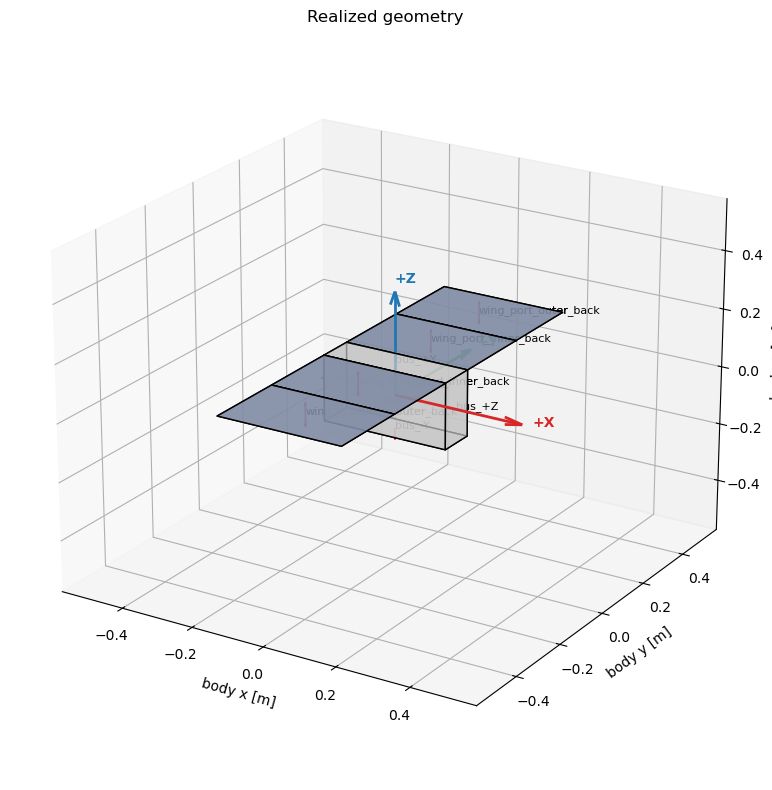

In [5]:
plot_realized_geometry(
    realized,
    title='Realized geometry',
    show_body_axes=True,
)
plt.show()


## Step 3: Verify body-axis mapping and save JSON

The saved artifact should match the attitude-law body frame:
- large `0.3405 x 0.2263` bus faces on body `+/-Y`
- target-facing bus face on body `+X`
- solar-panel normals on body `+Z`

The checks below validate that mounted role mapping before the notebook writes `outputs/spacecraft.json`.


In [6]:
bus_x, bus_y, bus_z = cubesat.metadata['bus_dimensions_m']
expected_large_bus_face = (bus_z, bus_y)
expected_target_face = (bus_x, bus_y)

body_plus_x_bus = surface_by_normal(realized, [1.0, 0.0, 0.0], tag='bus')
body_plus_y_bus = surface_by_normal(realized, [0.0, 1.0, 0.0], tag='bus')
body_minus_y_bus = surface_by_normal(realized, [0.0, -1.0, 0.0], tag='bus')
body_plus_z_panels = [
    surface for surface in realized.by_tag('solar_panel')
    if np.allclose(surface.normal, [0.0, 0.0, 1.0], atol=1e-9)
]
body_minus_z_panel_backs = [
    surface for surface in realized.by_tag('solar_panel_back')
    if np.allclose(surface.normal, [0.0, 0.0, -1.0], atol=1e-9)
]

assert np.allclose([body_plus_y_bus.width, body_plus_y_bus.height], expected_large_bus_face, atol=1e-12)
assert np.allclose([body_minus_y_bus.width, body_minus_y_bus.height], expected_large_bus_face, atol=1e-12)
assert np.allclose([body_plus_x_bus.width, body_plus_x_bus.height], expected_target_face, atol=1e-12)
assert len(body_plus_z_panels) == 4
assert len(body_minus_z_panel_backs) == 4

saved_path = realized.to_json(geometry_json_path)

print('saved geometry:', saved_path)
print('mount offset [m]:', mount_offset.tolist())
for label, axis in [('+X', [1.0, 0.0, 0.0]), ('+Y', [0.0, 1.0, 0.0]), ('+Z', [0.0, 0.0, 1.0])]:
    mapped = np.round(mount_rotation.apply(axis), 4)
    print(f'geometry {label} -> body {tuple(mapped.tolist())}')
print()
print('mounted role table:')
print_mounted_role_table(realized)
print()
print('body-axis role summary:')
print(
    f'  body +X target face   : {body_plus_x_bus.name} '
    f'(normal={tuple(np.round(body_plus_x_bus.normal, 4))}, size={body_plus_x_bus.width:.4f} x {body_plus_x_bus.height:.4f} m)'
)
print(
    f'  body +Y large bus face: {body_plus_y_bus.name} '
    f'(normal={tuple(np.round(body_plus_y_bus.normal, 4))}, size={body_plus_y_bus.width:.4f} x {body_plus_y_bus.height:.4f} m)'
)
print(
    f'  body -Y large bus face: {body_minus_y_bus.name} '
    f'(normal={tuple(np.round(body_minus_y_bus.normal, 4))}, size={body_minus_y_bus.width:.4f} x {body_minus_y_bus.height:.4f} m)'
)
print(
    '  body +Z solar-panel cell sides  :',
    [surface.name for surface in body_plus_z_panels],
)
print(
    '  body -Z solar-panel backs       :',
    [surface.name for surface in body_minus_z_panel_backs],
)
print()
print('attitude-law alignment:')
print('  umbra  : +X body -> target, +Z body -> nadir (secondary)')
print('  sunlit : +Z body -> sun, +X body -> zenith (secondary)')


saved geometry: outputs\spacecraft.json
mount offset [m]: [0.0, 0.0, 0.0]
geometry +X -> body (0.0, 1.0, 0.0)
geometry +Y -> body (0.0, 0.0, 1.0)
geometry +Z -> body (1.0, 0.0, 0.0)

mounted role table:
builder id               body role              normal   +u       +v       center [m]                     tags
--------------------------------------------------------------------------------------------------------------
bus_+X                   body +Y bus face       +Y       +X       -Z       (0.0, 0.05, 0.0)               bus, +X
bus_-X                   body -Y bus face       -Y       +X       +Z       (0.0, -0.05, 0.0)              bus, -X
bus_+Y                   body +Z bus face       +Z       +X       +Y       (0.0, 0.0, 0.1132)             bus, +Y
bus_-Y                   body -Z bus face       -Z       +X       -Y       (0.0, 0.0, -0.1132)            bus, -Y
bus_+Z                   body +X bus face       +X       +Y       +Z       (0.1703, 0.0, 0.0)             bus, +Z
bus_-